# EEG Artifact Denoising — State-of-the-Art Model

**Architecture:** Improved FCDenoiser → **EEGDenoisNet++**  
A residual fully-connected network augmented with:  
- Skip / residual connections (learn the *noise* residual, not the clean signal directly)  
- Squeeze-and-Excitation (SE) channel-wise attention on feature blocks  
- Spectral loss (FFT magnitude MSE) combined with time-domain MSE  
- Cosine-annealing with warm restarts LR schedule  
- Mixed-precision (FP16) training  
- Gradient clipping + EMA weights  
- Single model trained on **all 7 artifact combos** simultaneously  

**Dataset:** EEGDenoiseNet (Zhang et al., 2021) — 7 combos × 3 splits, 512-sample windows @ 256 Hz  
**Metrics:** MSE · RMSE · RRMSE · SNR (dB) · Spectral Loss


## 0 · Install & Imports

In [1]:
# ── install extras not present on Kaggle by default ──────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "h5py", "tqdm", "torchmetrics"], check=True)
print("✅ packages ready")

✅ packages ready


In [2]:
import os, glob, math, time, json
from pathlib import Path
from copy import deepcopy

import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.cuda.amp import GradScaler, autocast
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = False   # keep True only for full repro
torch.backends.cudnn.benchmark = True        # faster on fixed-size inputs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 1 · Configuration

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  USER CONFIG  ← edit the DATA_ROOT to match your Kaggle dataset path
# ─────────────────────────────────────────────────────────────────────────────
DATA_ROOT   = Path("/kaggle/input/datasets/lucky3663/eegdenoise")   # ← UPDATE THIS
OUTPUT_DIR  = Path("/kaggle/working")
CKPT_DIR    = OUTPUT_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── model / training hyper-params ────────────────────────────────────────────
WIN_LEN      = 512        # samples per window (fixed by dataset)
HIDDEN_DIMS  = [1024, 2048, 2048, 1024, 512]   # per residual block widths
SE_REDUCTION = 8          # squeeze-and-excite bottleneck ratio
DROPOUT      = 0.25

BATCH_SIZE   = 512        # fits P100 / T4 with AMP; halve for CPU
NUM_EPOCHS   = 60
LR_INIT      = 3e-3
LR_MIN       = 1e-5
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0
EMA_DECAY    = 0.999

# ── loss weights ─────────────────────────────────────────────────────────────
LAMBDA_TIME  = 1.0        # weight for time-domain MSE
LAMBDA_SPEC  = 0.3        # weight for spectral (FFT magnitude) MSE
LAMBDA_GRAD  = 0.1        # weight for temporal gradient loss

# ── cosine annealing with warm restarts ──────────────────────────────────────
T0           = 15         # first restart period (epochs)
T_MULT       = 2          # period multiplier after each restart

# ── artifact combos present in the dataset ───────────────────────────────────
COMBOS = ["emg", "eog", "ecg",
          "emg_eog", "emg_ecg", "eog_ecg",
          "emg_eog_ecg"]
SPLITS  = ["train", "val", "test"]

print("Config loaded ✅")
print(f"  Combos : {COMBOS}")
print(f"  Epochs : {NUM_EPOCHS}  |  Batch : {BATCH_SIZE}  |  LR : {LR_INIT}")

Config loaded ✅
  Combos : ['emg', 'eog', 'ecg', 'emg_eog', 'emg_ecg', 'eog_ecg', 'emg_eog_ecg']
  Epochs : 60  |  Batch : 512  |  LR : 0.003


## 2 · Dataset

In [4]:
class EEGDenoiseDataset(Dataset):
    """
    Loads one HDF5 file: {combo}_{split}.h5
    Keys: /clean  (N,512) float32
          /noisy  (N,512) float32
    Returns (noisy, clean) tensors already on CPU.
    """
    def __init__(self, h5_path: Path):
        super().__init__()
        with h5py.File(h5_path, 'r') as f:
            self.noisy = torch.from_numpy(f['noisy'][:].astype(np.float32))
            self.clean = torch.from_numpy(f['clean'][:].astype(np.float32))
        assert self.noisy.shape == self.clean.shape, "Shape mismatch in HDF5"
        assert self.noisy.shape[1] == WIN_LEN, f"Expected WIN_LEN={WIN_LEN}"

    def __len__(self):
        return self.noisy.shape[0]

    def __getitem__(self, idx):
        return self.noisy[idx], self.clean[idx]


def build_loaders(data_root: Path, combos: list, batch_size: int,
                  num_workers: int = 2):
    """
    Returns dict: {'train': DataLoader, 'val': DataLoader, 'test': DataLoader}
    Each loader is a ConcatDataset over all combos — single model sees every
    artifact type in every batch.
    """
    loaders = {}
    total_rows = {}
    for split in SPLITS:
        datasets = []
        for combo in combos:
            path = data_root / f"{combo}_{split}.h5"
            if not path.exists():
                raise FileNotFoundError(
                    f"Missing file: {path}\n"
                    f"Check DATA_ROOT = {data_root}"
                )
            datasets.append(EEGDenoiseDataset(path))
        combined = ConcatDataset(datasets)
        total_rows[split] = len(combined)
        shuffle = (split == 'train')
        loaders[split] = DataLoader(
            combined,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=(DEVICE.type == 'cuda'),
            drop_last=(split == 'train'),
            persistent_workers=(num_workers > 0),
        )
    print("DataLoaders built ✅")
    for s, n in total_rows.items():
        print(f"  {s:6s}: {n:,} samples")
    return loaders


loaders = build_loaders(DATA_ROOT, COMBOS, BATCH_SIZE)

DataLoaders built ✅
  train : 252,770 samples
  val   : 31,570 samples
  test  : 31,640 samples


## 3 · Model — EEGDenoisNet++

In [5]:
# ── Squeeze-and-Excitation attention on 1-D feature vectors ──────────────────
class SEBlock(nn.Module):
    """
    Applies channel-wise (feature-wise) self-attention:
        z = sigmoid( W2 · ReLU( W1 · global_avg(x) ) ) * x
    reduction: bottleneck ratio.
    """
    def __init__(self, channels: int, reduction: int = SE_REDUCTION):
        super().__init__()
        mid = max(channels // reduction, 16)
        self.fc = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):          # x: (B, C)
        return x * self.fc(x)      # element-wise gating


# ── Dense residual block ──────────────────────────────────────────────────────
class ResBlock(nn.Module):
    """
    in → Linear(in→out) → BN → GELU → Dropout → SE → + skip
    If in != out a linear projection adapts the skip.
    """
    def __init__(self, in_dim: int, out_dim: int,
                 dropout: float = DROPOUT):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            SEBlock(out_dim),
        )
        self.proj = (
            nn.Linear(in_dim, out_dim, bias=False)
            if in_dim != out_dim else nn.Identity()
        )

    def forward(self, x):
        return self.block(x) + self.proj(x)


# ── Main model ────────────────────────────────────────────────────────────────
class EEGDenoisNetPP(nn.Module):
    """
    EEGDenoisNet++: Residual FC denoiser with SE attention.

    Key design choices
    ------------------
    1. **Residual noise subtraction**: the network predicts the artifact
       (noise) and the final output is  x_clean = x_noisy − f(x_noisy).
       This is easier to learn than predicting clean EEG from scratch and
       is analogous to DnCNN in image denoising.

    2. **SE attention**: gating after every block lets the model focus
       on the frequency-band features most relevant to each artifact type.

    3. **GELU activations**: smoother gradients than ReLU, preferred for
       signal-processing tasks.

    4. **Single model, all combos**: artifact-type variability acts as a
       regulariser.

    Architecture:  512 → 1024 → 2048 → 2048 → 1024 → 512 → 512
    """
    def __init__(self,
                 win_len:     int   = WIN_LEN,
                 hidden_dims: list  = HIDDEN_DIMS,
                 dropout:     float = DROPOUT):
        super().__init__()

        dims   = [win_len] + hidden_dims + [win_len]
        blocks = []
        for i in range(len(dims) - 1):
            blocks.append(ResBlock(dims[i], dims[i+1], dropout))
        self.encoder = nn.Sequential(*blocks)

        # Final projection: learns to scale & shift noise estimate
        self.head = nn.Linear(win_len, win_len)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x_noisy):               # x_noisy: (B, 512)
        noise_est = self.head(self.encoder(x_noisy))   # predict artifact
        return x_noisy - noise_est             # subtract → clean estimate


model = EEGDenoisNetPP().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: EEGDenoisNet++  |  Parameters: {n_params:,}")
print(model)

Model: EEGDenoisNet++  |  Parameters: 17,978,880
EEGDenoisNetPP(
  (encoder): Sequential(
    (0): ResBlock(
      (block): Sequential(
        (0): Linear(in_features=512, out_features=1024, bias=True)
        (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.25, inplace=False)
        (4): SEBlock(
          (fc): Sequential(
            (0): Linear(in_features=1024, out_features=128, bias=False)
            (1): ReLU(inplace=True)
            (2): Linear(in_features=128, out_features=1024, bias=False)
            (3): Sigmoid()
          )
        )
      )
      (proj): Linear(in_features=512, out_features=1024, bias=False)
    )
    (1): ResBlock(
      (block): Sequential(
        (0): Linear(in_features=1024, out_features=2048, bias=True)
        (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3)

## 4 · Loss Functions

In [6]:
def spectral_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    MSE on FFT magnitude spectra — penalises spectral distortion.
    Uses rfft (real FFT) for efficiency.
    """
    eps = 1e-8
    P = torch.abs(torch.fft.rfft(pred,   norm='ortho')) + eps
    T = torch.abs(torch.fft.rfft(target, norm='ortho')) + eps
    return F.mse_loss(P, T)


def gradient_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Encourages temporal smoothness: MSE on first-order temporal differences.
    """
    dp = pred[:, 1:]   - pred[:, :-1]
    dt = target[:, 1:] - target[:, :-1]
    return F.mse_loss(dp, dt)


def combined_loss(pred, target,
                  lam_time=LAMBDA_TIME,
                  lam_spec=LAMBDA_SPEC,
                  lam_grad=LAMBDA_GRAD):
    """
    Total = λ_time · MSE_time + λ_spec · MSE_spec + λ_grad · MSE_grad
    Returns (total_loss, dict_of_components)
    """
    l_t = F.mse_loss(pred, target)
    l_s = spectral_loss(pred, target)
    l_g = gradient_loss(pred, target)
    total = lam_time * l_t + lam_spec * l_s + lam_grad * l_g
    return total, {'time': l_t.item(),
                   'spec': l_s.item(),
                   'grad': l_g.item()}


print("Loss functions defined ✅")

Loss functions defined ✅


## 5 · Metrics

In [7]:
@torch.no_grad()
def compute_metrics(pred: torch.Tensor,
                    target: torch.Tensor) -> dict:
    """
    All metrics computed on CPU, batch-averaged.

    MSE   : Mean Squared Error
    RMSE  : Root MSE
    RRMSE : Relative RMSE = RMSE / RMS(target)
    SNR   : Signal-to-Noise Ratio (dB)  = 10·log10( E[y²] / E[(ŷ−y)²] )
    SPEC  : Spectral MSE (FFT magnitudes)
    """
    pred   = pred.float().cpu()
    target = target.float().cpu()

    diff   = pred - target
    mse    = (diff ** 2).mean(dim=1)           # (B,)
    target_power = (target ** 2).mean(dim=1)   # (B,)

    rmse   = mse.sqrt()
    rrmse  = rmse / (target_power.sqrt() + 1e-8)
    snr_db = 10 * torch.log10(target_power / (mse + 1e-10))

    spec = spectral_loss(pred, target).item()

    return {
        'MSE'   : mse.mean().item(),
        'RMSE'  : rmse.mean().item(),
        'RRMSE' : rrmse.mean().item(),
        'SNR_dB': snr_db.mean().item(),
        'SpecLoss': spec,
    }


print("Metrics defined ✅")

Metrics defined ✅


## 6 · EMA Helper

In [8]:
class EMA:
    """
    Exponential Moving Average of model weights.
    Usage:
        ema = EMA(model, decay=0.999)
        # after each optimiser step:
        ema.update()
        # for inference:
        with ema.average_parameters():
            predictions = model(inputs)
    """
    def __init__(self, model: nn.Module, decay: float = EMA_DECAY):
        self.model  = model
        self.decay  = decay
        self.shadow = {name: param.data.clone()
                       for name, param in model.named_parameters()
                       if param.requires_grad}
        self._backup = {}

    @torch.no_grad()
    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = (
                    self.decay * self.shadow[name]
                    + (1 - self.decay) * param.data
                )

    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self._backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and name in self._backup:
                param.data.copy_(self._backup[name])
        self._backup.clear()

    class _ctx:
        def __init__(self, ema): self.ema = ema
        def __enter__(self):     self.ema.apply_shadow()
        def __exit__(self, *_):  self.ema.restore()

    def average_parameters(self):
        return self._ctx(self)

print("EMA helper defined ✅")

EMA helper defined ✅


## 7 · Checkpointing Utilities

In [9]:
BEST_CKPT  = CKPT_DIR / "best_model.pt"
LAST_CKPT  = CKPT_DIR / "last_model.pt"
HISTORY_F  = CKPT_DIR / "history.json"


def save_checkpoint(epoch, model, ema, optimizer, scheduler,
                    val_loss, is_best, history):
    state = {
        'epoch'      : epoch,
        'model'      : model.state_dict(),
        'ema_shadow' : ema.shadow,
        'optimizer'  : optimizer.state_dict(),
        'scheduler'  : scheduler.state_dict(),
        'val_loss'   : val_loss,
    }
    torch.save(state, LAST_CKPT)
    if is_best:
        torch.save(state, BEST_CKPT)
    with open(HISTORY_F, 'w') as f:
        json.dump(history, f, indent=2)


def load_checkpoint(path, model, ema, optimizer, scheduler):
    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state['model'])
    ema.shadow = state['ema_shadow']
    optimizer.load_state_dict(state['optimizer'])
    scheduler.load_state_dict(state['scheduler'])
    history = json.load(open(HISTORY_F)) if HISTORY_F.exists() else {}
    print(f"↩  Resumed from epoch {state['epoch']}  |  val_loss={state['val_loss']:.6f}")
    return state['epoch'], state['val_loss'], history


print("Checkpoint utils defined ✅")
print(f"  Best : {BEST_CKPT}")
print(f"  Last : {LAST_CKPT}")

Checkpoint utils defined ✅
  Best : /kaggle/working/checkpoints/best_model.pt
  Last : /kaggle/working/checkpoints/last_model.pt


## 8 · Optimiser & Scheduler

In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_INIT,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8,
)

# Cosine Annealing with Warm Restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=T0,
    T_mult=T_MULT,
    eta_min=LR_MIN,
)

# Mixed-precision scaler (no-op on CPU)
scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))

# EMA
ema = EMA(model, decay=EMA_DECAY)

# ── optionally resume from last checkpoint ────────────────────────────────────
START_EPOCH  = 0
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [],
           'val_MSE': [], 'val_RMSE': [],
           'val_RRMSE': [], 'val_SNR_dB': [],
           'val_SpecLoss': [], 'lr': []}

RESUME = LAST_CKPT.exists()
if RESUME:
    START_EPOCH, best_val_loss, history = load_checkpoint(
        LAST_CKPT, model, ema, optimizer, scheduler
    )
    START_EPOCH += 1   # continue from next epoch
else:
    print("Starting fresh training run.")

print(f"Optimiser : AdamW  |  LR : {LR_INIT}  |  WD : {WEIGHT_DECAY}")
print(f"Scheduler : CosineAnnealingWarmRestarts  T0={T0}  T_mult={T_MULT}")

Starting fresh training run.
Optimiser : AdamW  |  LR : 0.003  |  WD : 0.0001
Scheduler : CosineAnnealingWarmRestarts  T0=15  T_mult=2


/tmp/ipykernel_55/4119636997.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))


## 9 · Training Loop

In [11]:
def run_epoch(loader, model, optimizer, scaler, ema,
              scheduler, is_train: bool):
    """
    One epoch of training or validation.
    Returns (avg_loss, metrics_dict)
    """
    model.train(is_train)
    total_loss = 0.0
    all_preds, all_targets = [], []
    loss_components = {'time': 0.0, 'spec': 0.0, 'grad': 0.0}

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    phase = "Train" if is_train else "Val"

    pbar = tqdm(loader, desc=phase, leave=False,
                dynamic_ncols=True, colour='green' if is_train else 'blue')

    with ctx:
        for noisy, clean in pbar:
            noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                with autocast(enabled=(DEVICE.type == 'cuda')):
                    pred = model(noisy)
                    loss, comps = combined_loss(pred, clean)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
                ema.update()
            else:
                with ema.average_parameters():
                    pred = model(noisy)
                loss, comps = combined_loss(pred, clean)

            total_loss += loss.item()
            for k in loss_components:
                loss_components[k] += comps[k]

            # accumulate for metrics (keep on CPU to save VRAM)
            all_preds.append(pred.detach().cpu())
            all_targets.append(clean.detach().cpu())

            pbar.set_postfix({'loss': f"{loss.item():.5f}",
                              'lr'  : f"{optimizer.param_groups[0]['lr']:.2e}"})

    n = len(loader)
    avg_loss = total_loss / n
    for k in loss_components:
        loss_components[k] /= n

    preds_cat   = torch.cat(all_preds)
    targets_cat = torch.cat(all_targets)
    metrics = compute_metrics(preds_cat, targets_cat)
    metrics.update({'loss_time': loss_components['time'],
                    'loss_spec': loss_components['spec'],
                    'loss_grad': loss_components['grad']})
    return avg_loss, metrics


# ── main training loop ────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  Training EEGDenoisNet++  |  Epochs {START_EPOCH}→{NUM_EPOCHS-1}")
print(f"{'='*65}\n")

epoch_pbar = tqdm(range(START_EPOCH, NUM_EPOCHS),
                  desc="Epochs", total=NUM_EPOCHS,
                  initial=START_EPOCH,
                  dynamic_ncols=True, colour='cyan')

for epoch in epoch_pbar:
    t0 = time.time()

    train_loss, train_m = run_epoch(
        loaders['train'], model, optimizer, scaler, ema,
        scheduler, is_train=True
    )

    val_loss, val_m = run_epoch(
        loaders['val'], model, optimizer, scaler, ema,
        scheduler, is_train=False
    )

    # step scheduler once per epoch (after val)
    scheduler.step(epoch + 1)

    elapsed = time.time() - t0
    cur_lr  = optimizer.param_groups[0]['lr']
    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss

    # ── record history ──────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_MSE'].append(val_m['MSE'])
    history['val_RMSE'].append(val_m['RMSE'])
    history['val_RRMSE'].append(val_m['RRMSE'])
    history['val_SNR_dB'].append(val_m['SNR_dB'])
    history['val_SpecLoss'].append(val_m['SpecLoss'])
    history['lr'].append(cur_lr)

    # ── checkpoint ──────────────────────────────────────────────────────────
    save_checkpoint(epoch, model, ema, optimizer, scheduler,
                    val_loss, is_best, history)

    # ── progress bar suffix ─────────────────────────────────────────────────
    epoch_pbar.set_postfix({
        'tr_loss' : f"{train_loss:.5f}",
        'vl_loss' : f"{val_loss:.5f}",
        'SNR_dB'  : f"{val_m['SNR_dB']:.2f}",
        'RRMSE'   : f"{val_m['RRMSE']:.4f}",
        'best'    : '★' if is_best else ''
    })

    # ── console log every 5 epochs ──────────────────────────────────────────
    if (epoch % 5 == 0) or is_best:
        flag = " ★ BEST" if is_best else ""
        print(f"Ep {epoch:03d}/{NUM_EPOCHS-1} "
              f"| tr {train_loss:.5f} "
              f"| vl {val_loss:.5f}{flag}\n"
              f"          MSE={val_m['MSE']:.6f}  "
              f"RMSE={val_m['RMSE']:.6f}  "
              f"RRMSE={val_m['RRMSE']:.4f}  "
              f"SNR={val_m['SNR_dB']:.2f}dB  "
              f"SpecL={val_m['SpecLoss']:.6f}  "
              f"lr={cur_lr:.2e}  ({elapsed:.1f}s)")

print(f"\nTraining complete.  Best val loss: {best_val_loss:.6f}")


  Training EEGDenoisNet++  |  Epochs 0→59



Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

Train:   0%|          | 0/493 [00:00<?, ?it/s]

/tmp/ipykernel_55/2832669543.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Val:   0%|          | 0/62 [00:00<?, ?it/s]

...

Train:   0%|          | 0/493 [00:00<?, ?it/s]

Val:   0%|          | 0/62 [00:00<?, ?it/s]

Train:   0%|          | 0/493 [00:00<?, ?it/s]

Val:   0%|          | 0/62 [00:00<?, ?it/s]


Training complete.  Best val loss: 0.041140


## 10 · Evaluation on Test Set

In [12]:
# ── load best weights ─────────────────────────────────────────────────────────
best_state = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(best_state['model'])
ema.shadow = best_state['ema_shadow']
print(f"Loaded best checkpoint (epoch {best_state['epoch']}, "
      f"val_loss={best_state['val_loss']:.6f})")


@torch.no_grad()
def evaluate_per_combo(data_root, combos, split='test'):
    """
    Evaluate separately on each artifact combo and return a summary table.
    """
    model.eval()
    summary = []

    for combo in tqdm(combos, desc="Evaluating combos"):
        path = data_root / f"{combo}_{split}.h5"
        ds   = EEGDenoiseDataset(path)
        dl   = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(DEVICE.type=='cuda'))

        preds, targets = [], []
        for noisy, clean in dl:
            noisy = noisy.to(DEVICE)
            with ema.average_parameters():
                pred = model(noisy)
            preds.append(pred.cpu())
            targets.append(clean)

        preds_cat   = torch.cat(preds)
        targets_cat = torch.cat(targets)
        m = compute_metrics(preds_cat, targets_cat)
        m['combo'] = combo
        m['n_samples'] = len(ds)
        summary.append(m)

    return summary


test_results = evaluate_per_combo(DATA_ROOT, COMBOS, split='test')

# ── pretty-print table ────────────────────────────────────────────────────────
hdr = f"{'Combo':<14} {'N':>7} {'MSE':>10} {'RMSE':>10} {'RRMSE':>8} {'SNR(dB)':>9} {'SpecLoss':>10}"
print("\n" + "=" * len(hdr))
print("  TEST RESULTS — EEGDenoisNet++  (EMA weights)")
print("=" * len(hdr))
print(hdr)
print("-" * len(hdr))
for r in test_results:
    print(f"{r['combo']:<14} {r['n_samples']:>7,} "
          f"{r['MSE']:>10.6f} {r['RMSE']:>10.6f} "
          f"{r['RRMSE']:>8.4f} {r['SNR_dB']:>9.3f} "
          f"{r['SpecLoss']:>10.6f}")

# overall average
keys = ['MSE','RMSE','RRMSE','SNR_dB','SpecLoss']
avg  = {k: np.mean([r[k] for r in test_results]) for k in keys}
print("-" * len(hdr))
total_n = sum(r['n_samples'] for r in test_results)
print(f"{'AVERAGE':<14} {total_n:>7,} "
      f"{avg['MSE']:>10.6f} {avg['RMSE']:>10.6f} "
      f"{avg['RRMSE']:>8.4f} {avg['SNR_dB']:>9.3f} "
      f"{avg['SpecLoss']:>10.6f}")
print("=" * len(hdr))

Loaded best checkpoint (epoch 14, val_loss=0.041140)


Evaluating combos:   0%|          | 0/7 [00:00<?, ?it/s]


  TEST RESULTS — EEGDenoisNet++  (EMA weights)
Combo                N        MSE       RMSE    RRMSE   SNR(dB)   SpecLoss
--------------------------------------------------------------------------
emg              4,520   0.047735   0.206162   0.4963     7.371   0.030282
eog              4,520   0.009789   0.092157   0.2151    14.469   0.005508
ecg              4,520   0.043550   0.196094   0.3741     9.976   0.024738
emg_eog          4,520   0.030549   0.164532   0.5061     7.169   0.018148
emg_ecg          4,520   0.047460   0.205901   0.5706     6.037   0.028015
eog_ecg          4,520   0.027000   0.154590   0.4344     8.654   0.014458
emg_eog_ecg      4,520   0.035078   0.177377   0.5966     5.646   0.020041
--------------------------------------------------------------------------
AVERAGE         31,640   0.034452   0.170973   0.4562     8.475   0.020170


## 11 · Training Curves

ValueError: x and y must have same first dimension, but have shapes (60,) and (0,)

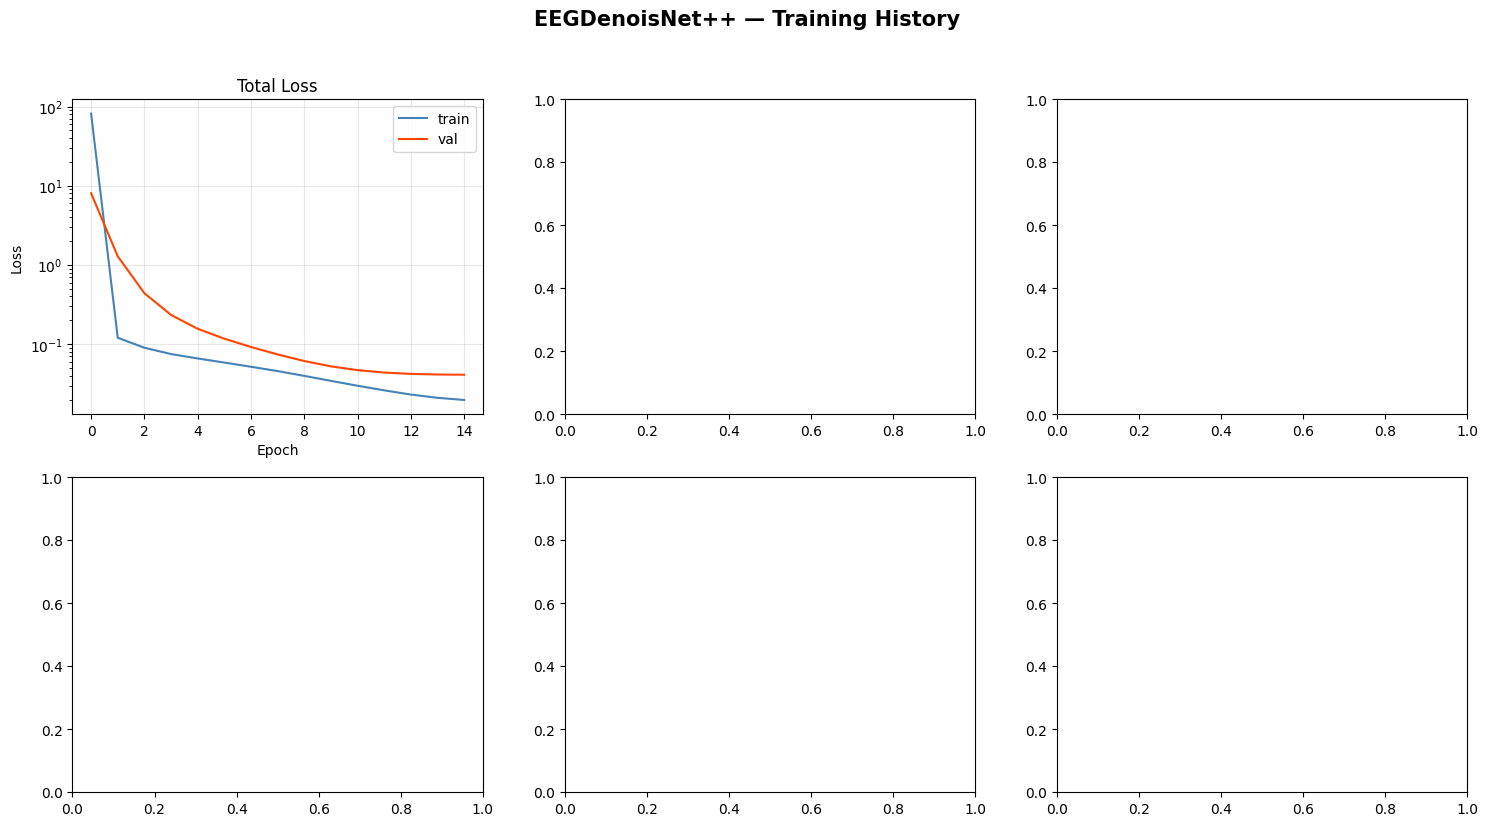

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("EEGDenoisNet++ — Training History", fontsize=15, fontweight='bold')

epochs_x = list(range(len(history['train_loss'])))

def _plot(ax, y_train, y_val, title, ylabel, log=False):
    ax.plot(epochs_x, y_train, label='train', color='steelblue', lw=1.5)
    if y_val:
        ax.plot(epochs_x, y_val, label='val', color='orangered', lw=1.5)
    if log:
        ax.set_yscale('log')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

_plot(axes[0,0], history['train_loss'], history['val_loss'],
      'Total Loss', 'Loss', log=True)
_plot(axes[0,1], [], history['val_MSE'],
      'Validation MSE', 'MSE', log=True)
_plot(axes[0,2], [], history['val_RMSE'],
      'Validation RMSE', 'RMSE')
_plot(axes[1,0], [], history['val_RRMSE'],
      'Validation RRMSE', 'RRMSE')
_plot(axes[1,1], [], history['val_SNR_dB'],
      'Validation SNR (dB)', 'dB')
_plot(axes[1,2], history['lr'], [],
      'Learning Rate', 'LR', log=True)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → training_curves.png")

## 12 · Per-Combo Metric Bar Charts

/tmp/ipykernel_55/3319624976.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos_labels, rotation=35, ha='right', fontsize=8)
/tmp/ipykernel_55/3319624976.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos_labels, rotation=35, ha='right', fontsize=8)
/tmp/ipykernel_55/3319624976.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos_labels, rotation=35, ha='right', fontsize=8)
/tmp/ipykernel_55/3319624976.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos_labels, rotation=35, ha='right', fontsize=8)
/tmp/ipykernel_55/3319624976.py:20: UserWarning: set

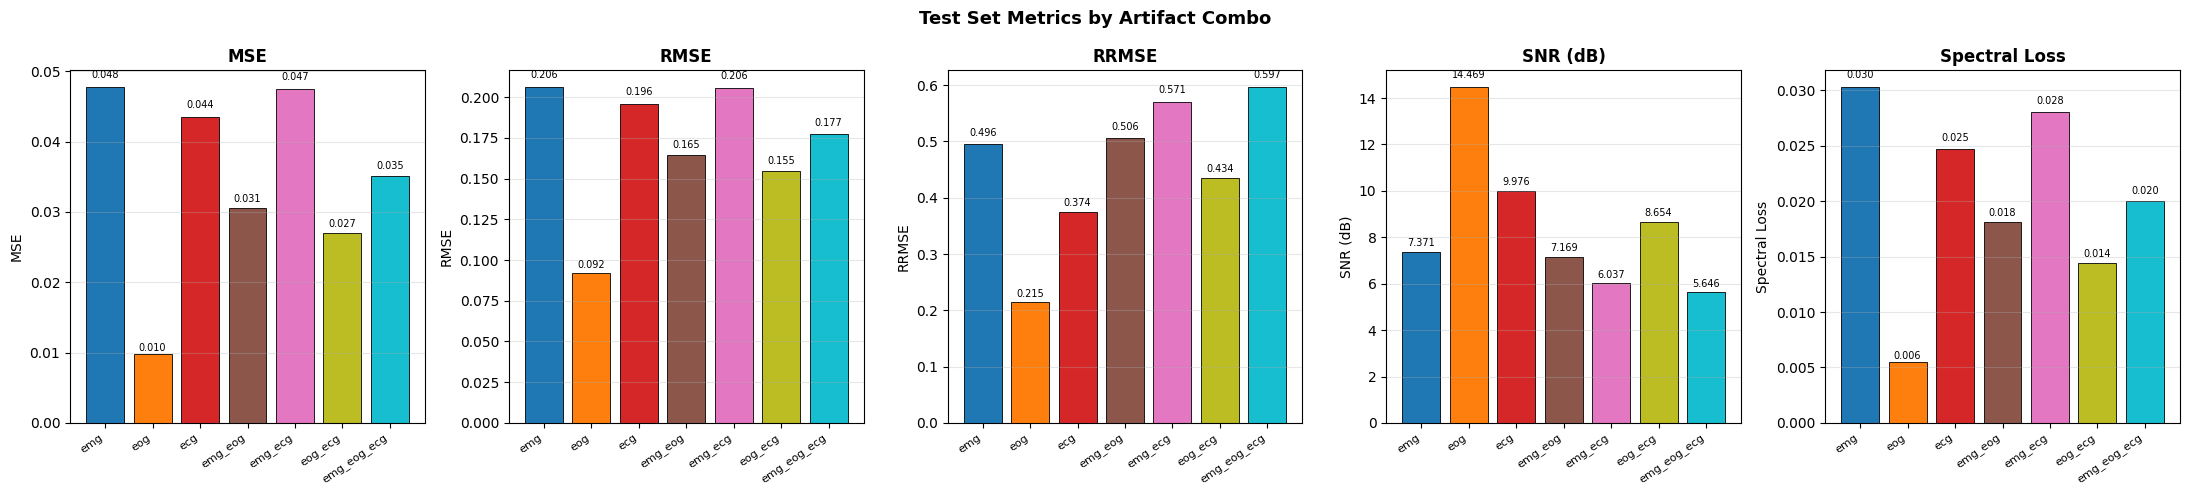

Saved → per_combo_metrics.png


In [14]:
combos_labels = [r['combo'] for r in test_results]
metrics_to_plot = [
    ('MSE',      'MSE',      False),
    ('RMSE',     'RMSE',     False),
    ('RRMSE',    'RRMSE',    False),
    ('SNR_dB',   'SNR (dB)', False),
    ('SpecLoss', 'Spectral Loss', False),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Test Set Metrics by Artifact Combo",
             fontsize=13, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(combos_labels)))

for ax, (key, label, _) in zip(axes, metrics_to_plot):
    vals = [r[key] for r in test_results]
    bars = ax.bar(combos_labels, vals, color=colors, edgecolor='black', lw=0.6)
    ax.set_title(label, fontweight='bold')
    ax.set_xticklabels(combos_labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f"{v:.3f}", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'per_combo_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → per_combo_metrics.png")

## 13 · Visual Denoising Examples

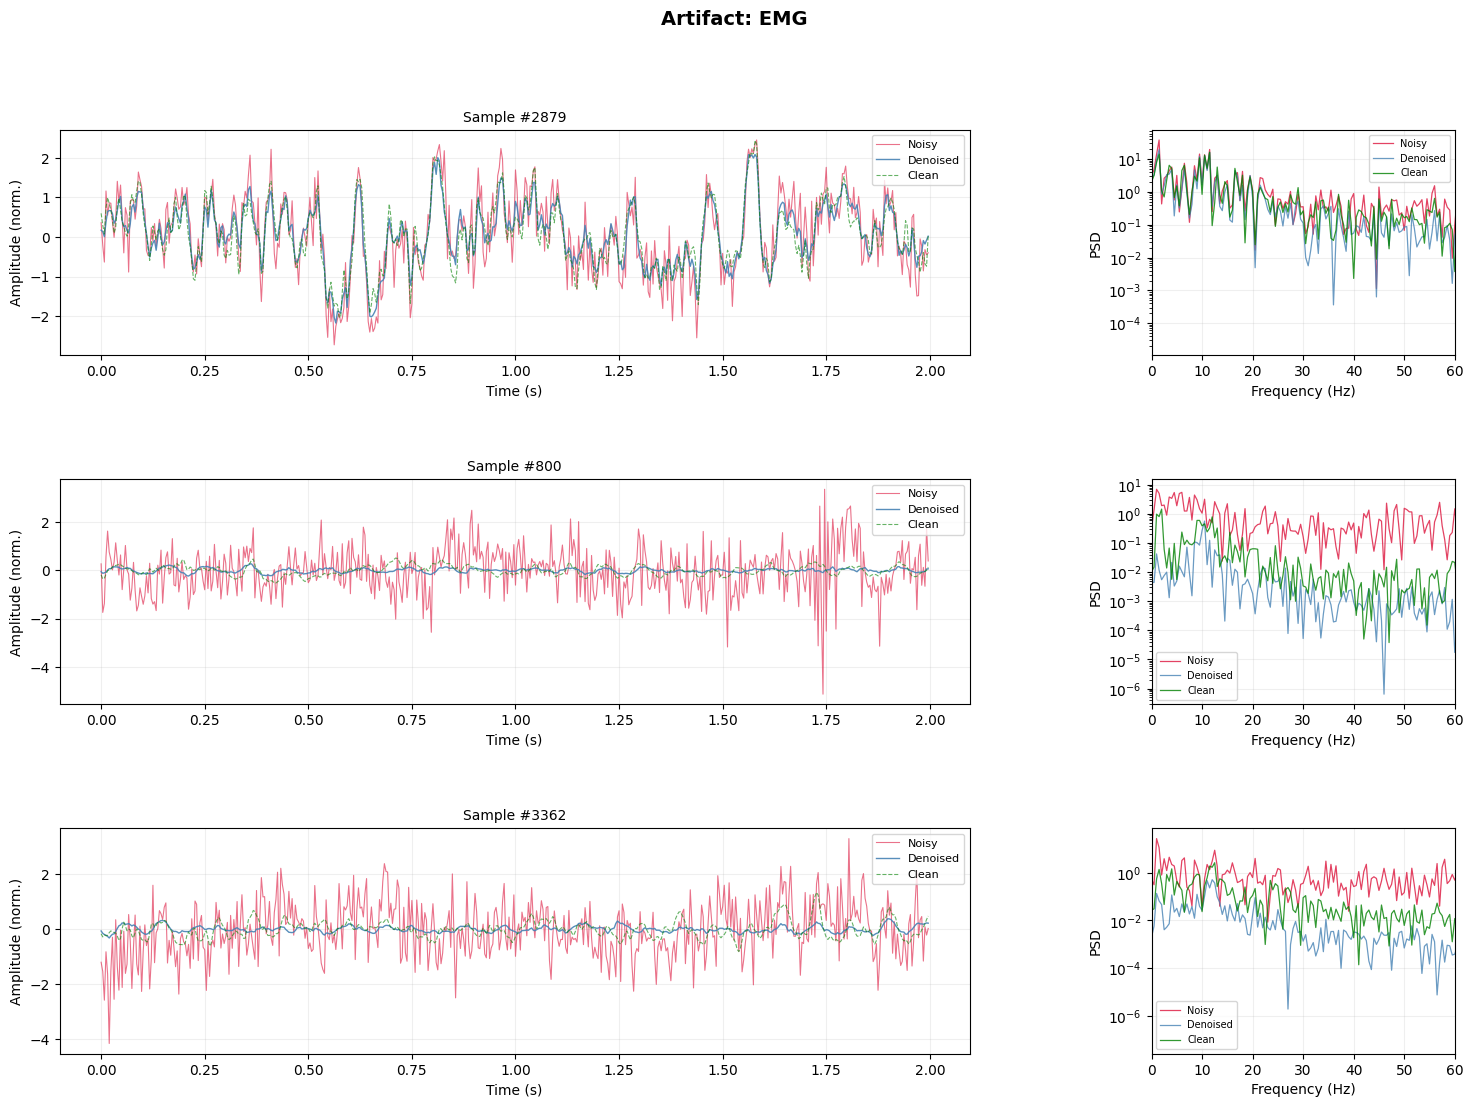

Saved → examples_emg.png


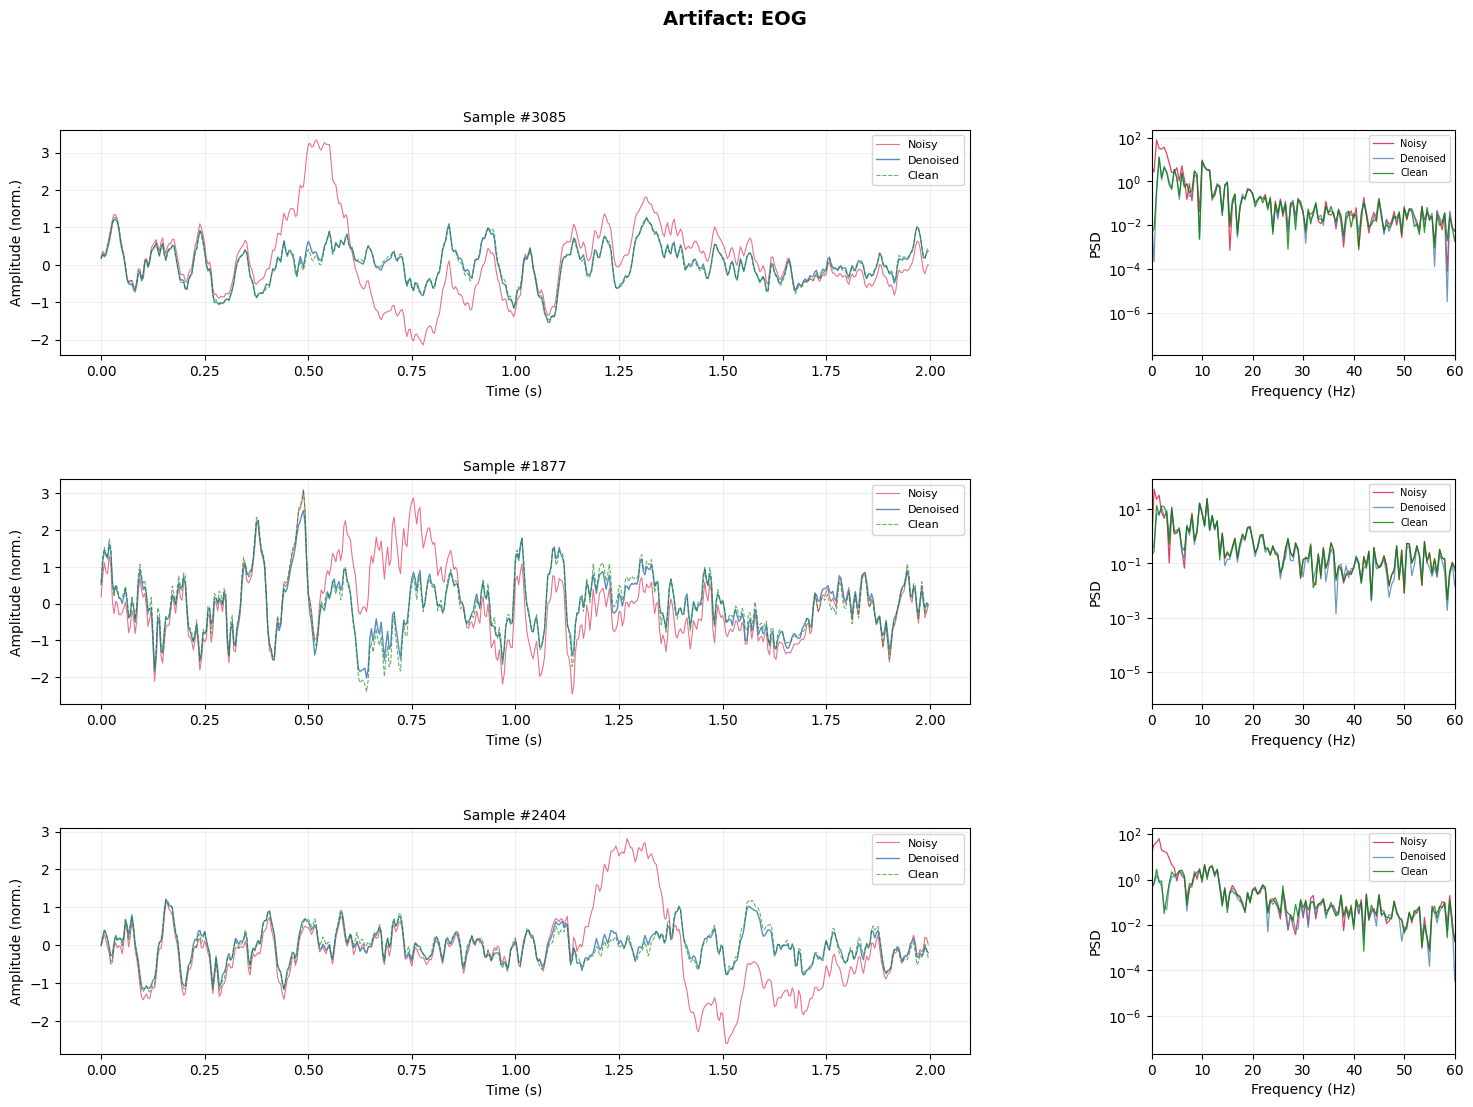

Saved → examples_eog.png


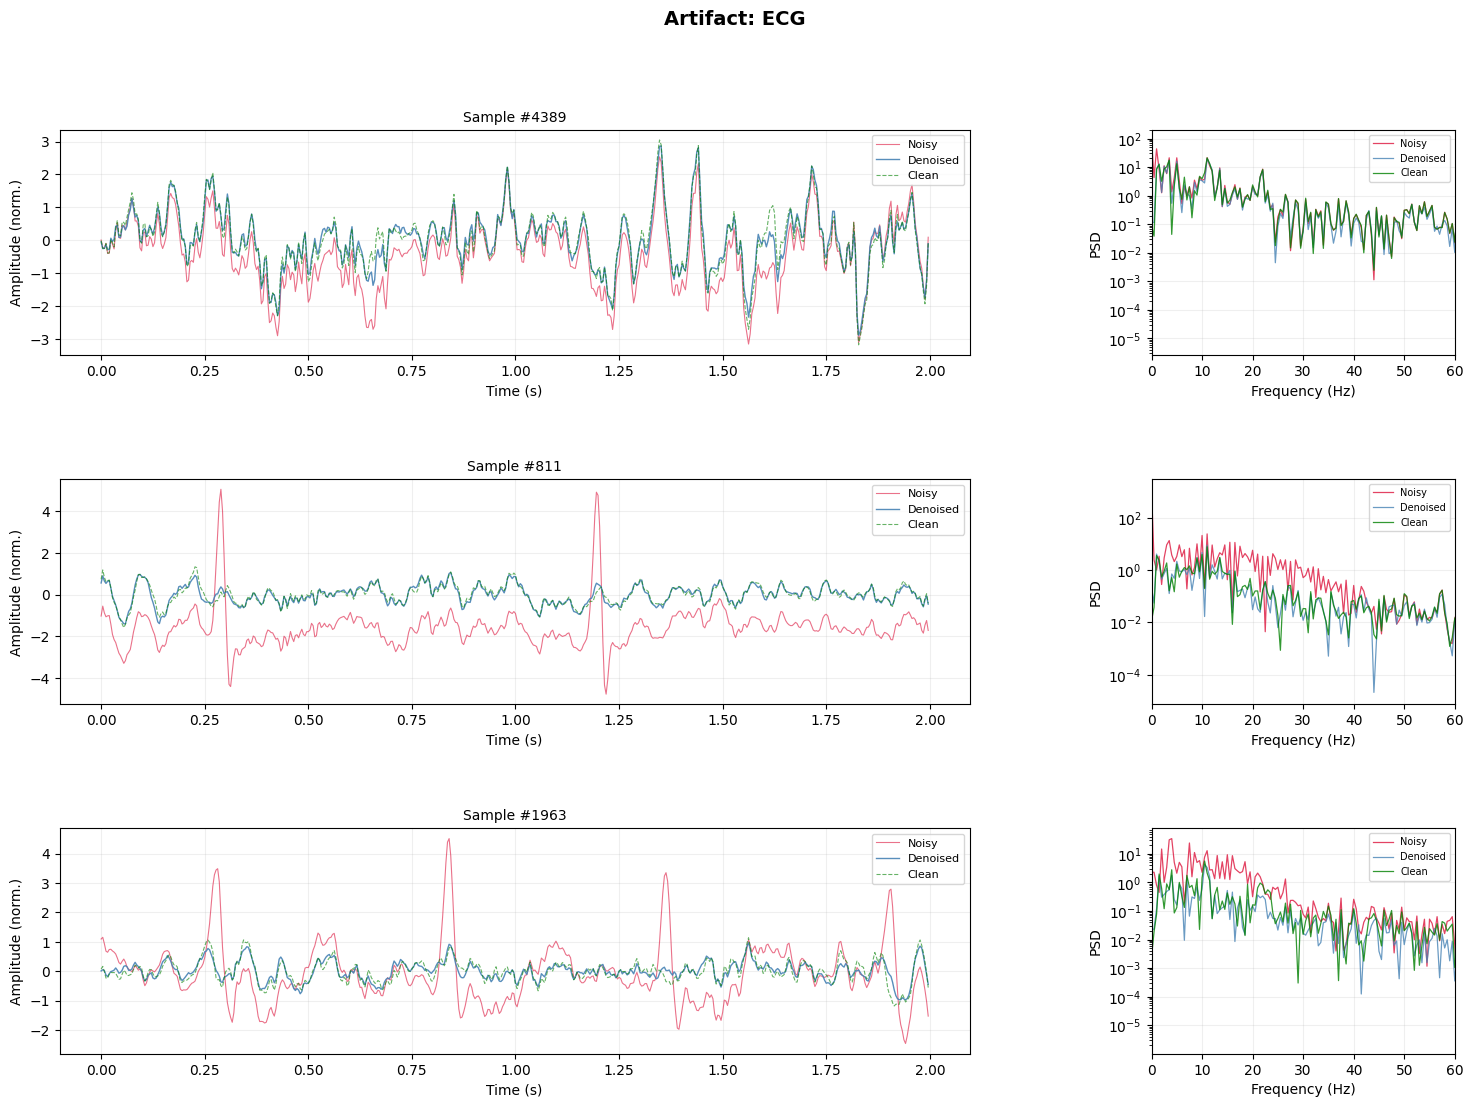

Saved → examples_ecg.png


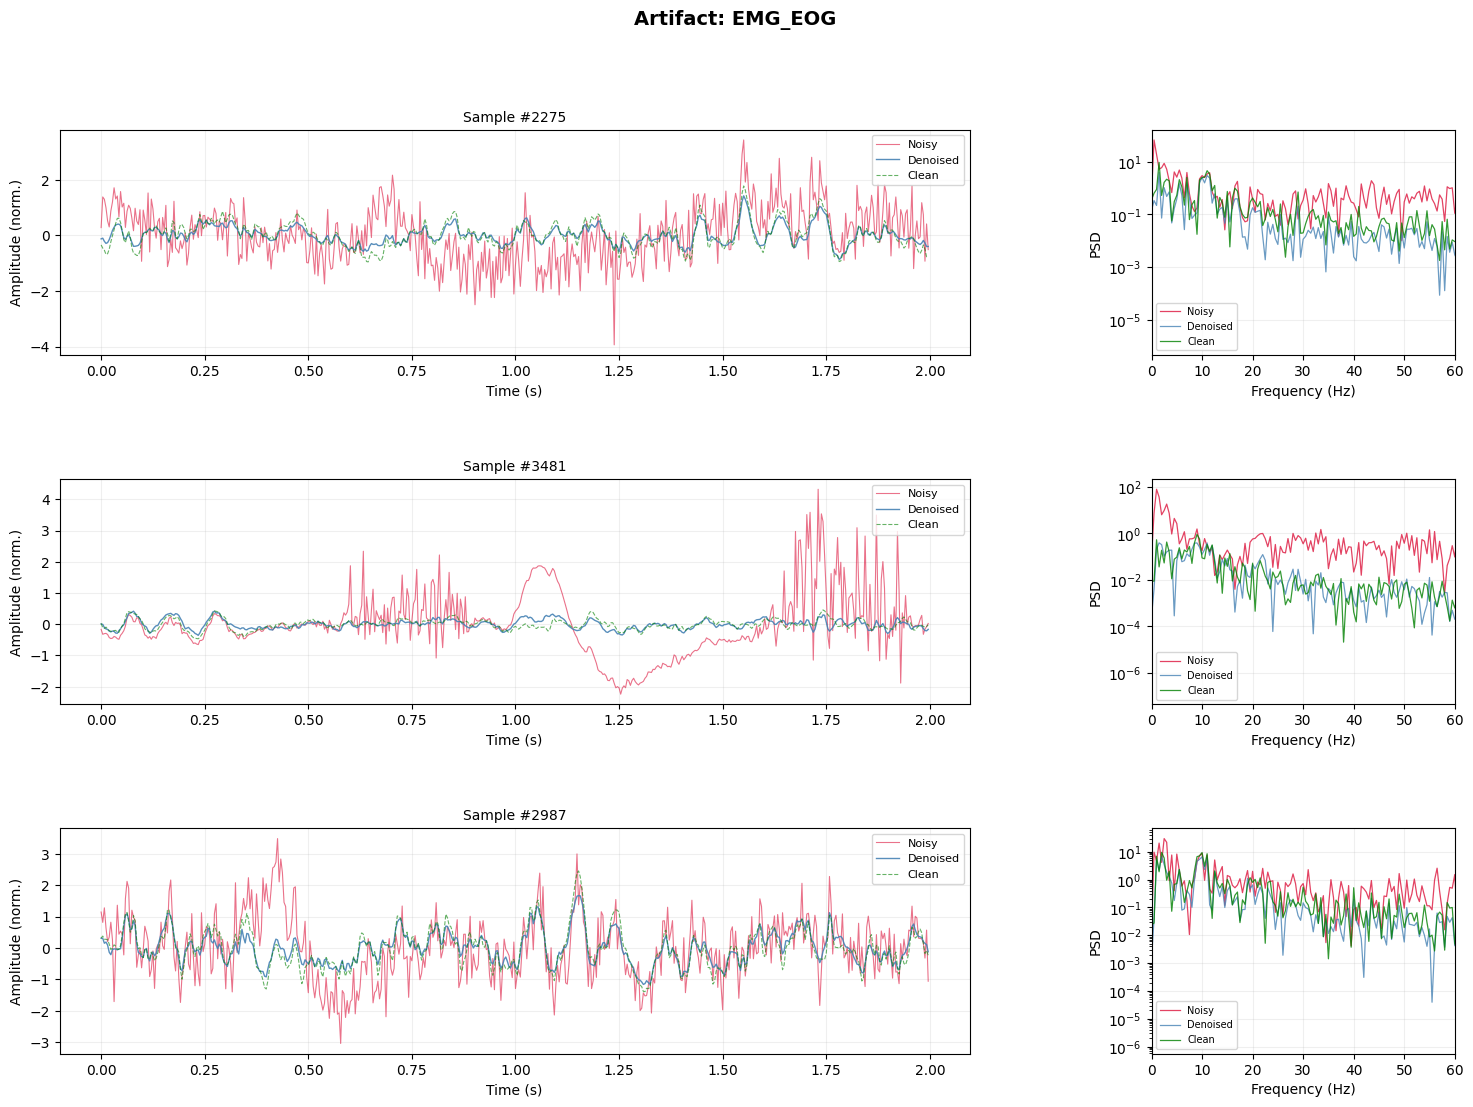

Saved → examples_emg_eog.png


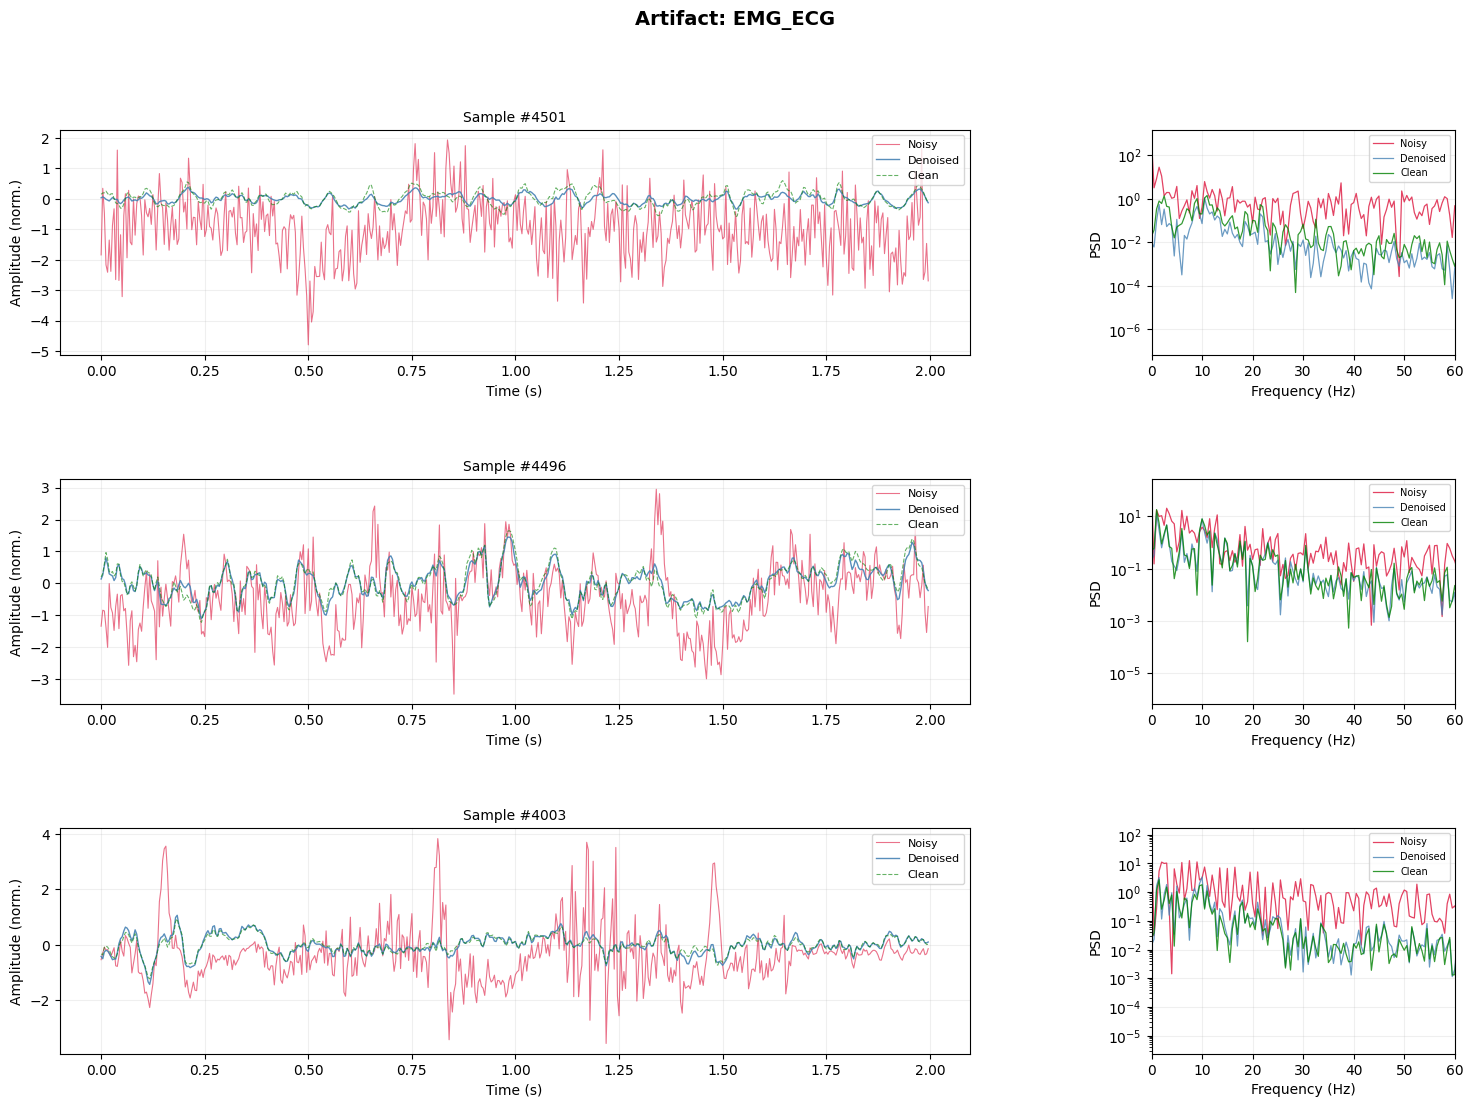

Saved → examples_emg_ecg.png


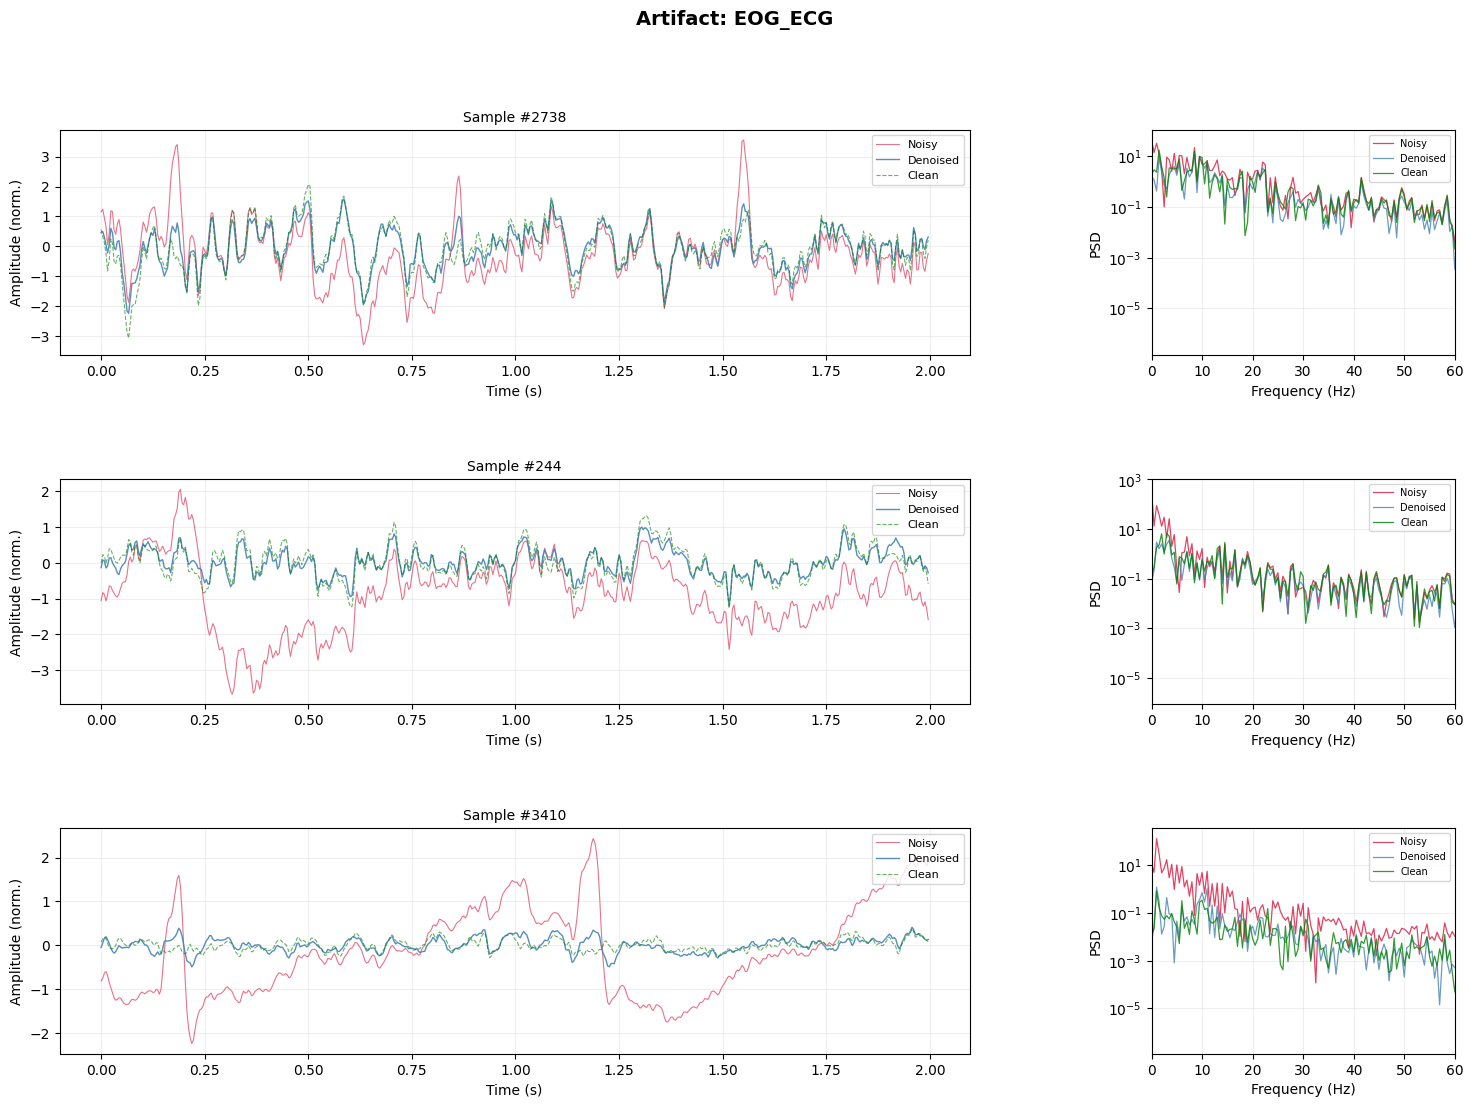

Saved → examples_eog_ecg.png


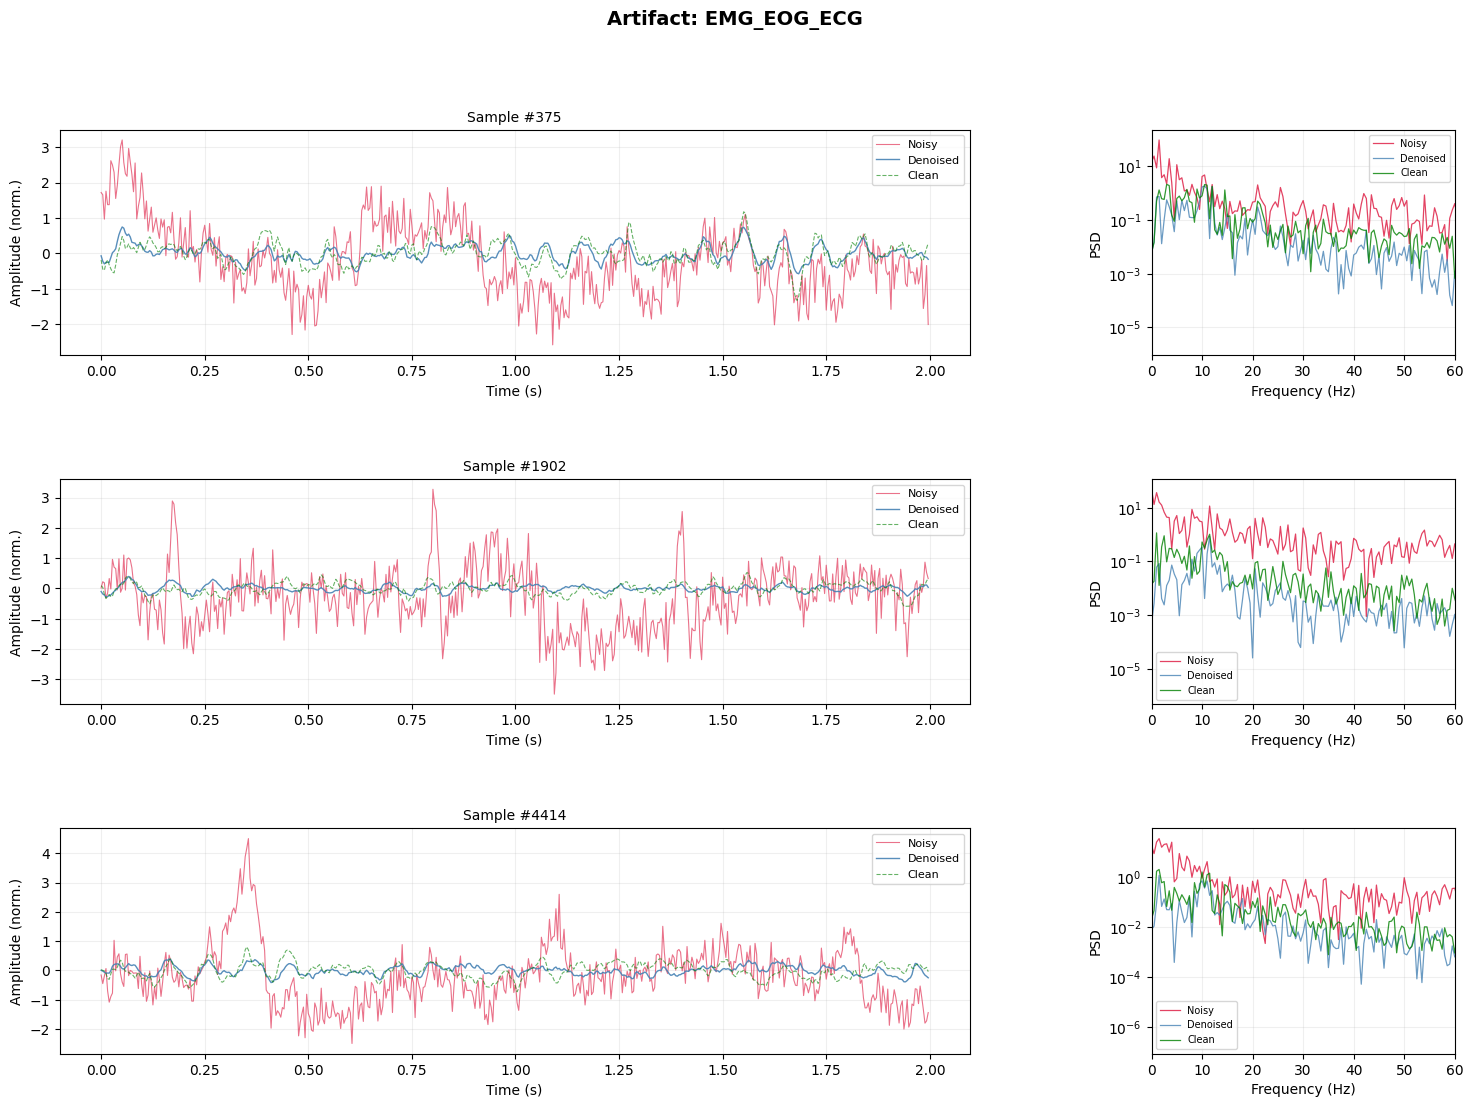

Saved → examples_emg_eog_ecg.png


In [15]:
@torch.no_grad()
def visualise_samples(data_root, combos, n_examples=3, split='test'):
    """
    For each combo: plot n_examples of (noisy | denoised | clean) + PSD.
    """
    model.eval()
    FS = 256  # Hz

    for combo in combos:
        path = data_root / f"{combo}_{split}.h5"
        ds   = EEGDenoiseDataset(path)
        idxs = np.random.choice(len(ds), n_examples, replace=False)

        fig  = plt.figure(figsize=(18, 4 * n_examples))
        fig.suptitle(f"Artifact: {combo.upper()}",
                     fontsize=14, fontweight='bold')
        gs   = gridspec.GridSpec(n_examples, 2, figure=fig,
                                 width_ratios=[3, 1], hspace=0.55, wspace=0.3)

        for row, idx in enumerate(idxs):
            noisy_t, clean_t = ds[idx]
            noisy_in = noisy_t.unsqueeze(0).to(DEVICE)
            with ema.average_parameters():
                denoised_t = model(noisy_in).squeeze(0).cpu()

            t = np.arange(WIN_LEN) / FS

            # ── time domain ─────────────────────────────────────────────────
            ax_t = fig.add_subplot(gs[row, 0])
            ax_t.plot(t, noisy_t.numpy(),    alpha=0.6, lw=0.8,
                      label='Noisy',    color='crimson')
            ax_t.plot(t, denoised_t.numpy(), alpha=0.9, lw=1.0,
                      label='Denoised', color='steelblue')
            ax_t.plot(t, clean_t.numpy(),    alpha=0.6, lw=0.8,
                      label='Clean',    color='green',  ls='--')
            ax_t.set_xlabel('Time (s)'); ax_t.set_ylabel('Amplitude (norm.)')
            ax_t.set_title(f'Sample #{idx}', fontsize=10)
            ax_t.legend(fontsize=8, loc='upper right'); ax_t.grid(alpha=0.2)

            # ── PSD ─────────────────────────────────────────────────────────
            ax_f = fig.add_subplot(gs[row, 1])
            for sig, col, lbl in [
                (noisy_t.numpy(),    'crimson',   'Noisy'),
                (denoised_t.numpy(), 'steelblue', 'Denoised'),
                (clean_t.numpy(),    'green',     'Clean'),
            ]:
                freqs = np.fft.rfftfreq(WIN_LEN, 1/FS)
                psd   = (np.abs(np.fft.rfft(sig, norm='ortho')) ** 2)
                ax_f.semilogy(freqs, psd, color=col, alpha=0.8,
                              lw=0.9, label=lbl)
            ax_f.set_xlabel('Frequency (Hz)'); ax_f.set_ylabel('PSD')
            ax_f.set_xlim(0, 60); ax_f.legend(fontsize=7); ax_f.grid(alpha=0.2)

        fig.savefig(OUTPUT_DIR / f'examples_{combo}.png',
                    dpi=130, bbox_inches='tight')
        plt.show()
        print(f"Saved → examples_{combo}.png")


visualise_samples(DATA_ROOT, COMBOS, n_examples=3)

## 14 · Export & Summary

In [16]:
import pandas as pd

# ── save test results CSV ─────────────────────────────────────────────────────
df = pd.DataFrame(test_results)
cols = ['combo', 'n_samples', 'MSE', 'RMSE', 'RRMSE', 'SNR_dB', 'SpecLoss']
df = df[cols].round(6)
csv_path = OUTPUT_DIR / 'test_metrics.csv'
df.to_csv(csv_path, index=False)
print(f"Test metrics saved → {csv_path}")
print(df.to_string(index=False))

# ── export traced model (optional, for deployment) ────────────────────────────
model.eval()
with ema.average_parameters():
    dummy  = torch.zeros(1, WIN_LEN, device=DEVICE)
    traced = torch.jit.trace(model, dummy)
    traced.save(str(OUTPUT_DIR / 'eeg_denoisnet_pp_ema.pt'))
print("TorchScript model saved → eeg_denoisnet_pp_ema.pt")

# ── final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  FINAL SUMMARY")
print("="*55)
print(f"  Model           : EEGDenoisNet++")
print(f"  Parameters      : {n_params:,}")
print(f"  Best val epoch  : {best_state['epoch']}")
print(f"  Best val loss   : {best_state['val_loss']:.6f}")
print(f"  Avg test MSE    : {avg['MSE']:.6f}")
print(f"  Avg test RMSE   : {avg['RMSE']:.6f}")
print(f"  Avg test RRMSE  : {avg['RRMSE']:.4f}")
print(f"  Avg test SNR    : {avg['SNR_dB']:.3f} dB")
print(f"  Avg test SpecL  : {avg['SpecLoss']:.6f}")
print("="*55)
print("\nOutput files in /kaggle/working/:")
for f in sorted(OUTPUT_DIR.glob('*')):
    if f.is_file():
        print(f"  {f.name}  ({f.stat().st_size/1e3:.1f} KB)")

Test metrics saved → /kaggle/working/test_metrics.csv
      combo  n_samples      MSE     RMSE    RRMSE    SNR_dB  SpecLoss
        emg       4520 0.047735 0.206162 0.496251  7.371405  0.030282
        eog       4520 0.009789 0.092157 0.215054 14.469421  0.005508
        ecg       4520 0.043550 0.196094 0.374079  9.976383  0.024738
    emg_eog       4520 0.030549 0.164532 0.506103  7.168899  0.018148
    emg_ecg       4520 0.047460 0.205901 0.570606  6.037027  0.028015
    eog_ecg       4520 0.027000 0.154590 0.434394  8.653906  0.014458
emg_eog_ecg       4520 0.035078 0.177377 0.596592  5.645665  0.020041
TorchScript model saved → eeg_denoisnet_pp_ema.pt

  FINAL SUMMARY
  Model           : EEGDenoisNet++
  Parameters      : 17,978,880
  Best val epoch  : 14
  Best val loss   : 0.041140
  Avg test MSE    : 0.034452
  Avg test RMSE   : 0.170973
  Avg test RRMSE  : 0.4562
  Avg test SNR    : 8.475 dB
  Avg test SpecL  : 0.020170

Output files in /kaggle/working/:
  eeg_denoisnet_pp_ema.

In [18]:
!zip results.zip *.pt *.png *.csv

  adding: eeg_denoisnet_pp_ema.pt (deflated 7%)
  adding: examples_ecg.png (deflated 3%)
  adding: examples_emg_ecg.png (deflated 3%)
  adding: examples_emg_eog_ecg.png (deflated 3%)
  adding: examples_emg_eog.png (deflated 3%)
  adding: examples_emg.png (deflated 3%)
  adding: examples_eog_ecg.png (deflated 3%)
  adding: examples_eog.png (deflated 3%)
  adding: per_combo_metrics.png (deflated 21%)
  adding: test_metrics.csv (deflated 46%)
